In [48]:
import numpy as np
import pandas as pd
import cv2
import os
from tqdm import tqdm
from glob import glob

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
)

In [20]:
DIR = './state-farm-distracted-driver-detection'

df = pd.read_csv(os.path.join(DIR, 'driver_imgs_list.csv'))

In [25]:
num_classes = 10

def get_image(path, num_rows, num_cols, is_grayscale=True):
    if is_grayscale:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (num_rows, num_cols))
    return img

def load_train_data(num_rows=64, num_cols=64, is_grayscale=True):
    train_images=[]
    train_labels=[]
    
    for classes in tqdm(range(num_classes)):
        print('Loading directory c{}'.format(classes))
        files = glob(os.path.join(DIR, 'imgs/train/c' + str(classes), '*.jpg'))
        for file in files:
            img = get_image(file, num_rows, num_cols, is_grayscale)
            train_images.append(img)
            train_labels.append(classes)
    return train_images, train_labels

def get_data(num_rows, num_cols, is_grayscale=True):
    X, labels = load_train_data(num_rows, num_cols, is_grayscale)
    y = to_categorical(labels, 10)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    X_train = np.array(X_train, dtype=np.uint8).reshape(-1, num_rows, num_cols, 1 if is_grayscale else 3)
    X_test = np.array(X_test, dtype=np.uint8).reshape(-1, num_rows, num_cols, 1 if is_grayscale else 3)
    
    return X_train, X_test, y_train, y_test

In [26]:
num_rows = 64
num_cols = 64
is_grayscale = True

X_train, X_test, y_train, y_test = get_data(num_rows, num_cols, is_grayscale)

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

Loading directory c0


 10%|████████▎                                                                          | 1/10 [00:05<00:47,  5.26s/it]

Loading directory c1


 20%|████████████████▌                                                                  | 2/10 [00:10<00:41,  5.22s/it]

...

 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [00:42<00:10,  5.26s/it]

Loading directory c8


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:47<00:05,  5.07s/it]

Loading directory c9


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:52<00:00,  5.22s/it]


In [27]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

In [28]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

In [38]:
batch_size = 40
epochs = 10

def create_model():
    
    model = Sequential()

    model.add(Input(shape=(num_rows, num_cols, 1 if is_grayscale else 3)))

    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))
    
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2), padding='same'))
    model.add(Dropout(0.25))

    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Dense(num_classes,activation='softmax'))
    
    return model

In [39]:
model = create_model()
model.summary()

model.compile(optimizer='rmsprop', metrics=['accuracy'], loss='categorical_crossentropy')

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 30, 30, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 13, 13, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 162,314 (634.04 KB)

 Trainable params: 161,098 (629.29 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [40]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1)

print(history.history)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - accuracy: 0.3258 - loss: 1.9872 - val_accuracy: 0.5088 - val_loss: 1.3634
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 144s 212ms/step - accuracy: 0.6723 - loss: 0.9370 - val_accuracy: 0.8341 - val_loss: 0.5020
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 210ms/step - accuracy: 0.8179 - loss: 0.5476 - val_accuracy: 0.6787 - val_loss: 1.1123
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 141s 208ms/step - accuracy: 0.8687 - loss: 0.3888 - val_accuracy: 0.9115 - val_loss: 0.2541
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 92s 206ms/step - accuracy: 0.9031 - loss: 0.2989 - val_accuracy: 0.8827 - val_loss: 0.3715
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.9161 - loss: 0.2584 - val_accuracy: 0.8870 - val_loss: 0.3309
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 145s 214ms/step - accuracy: 0.9294 - loss: 0.2186 - val_accuracy: 0.9382 - val_loss: 0.1946
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 86s 192ms/step - accuracy: 0.9386 - lo

In [43]:
model.save("saved_model.keras")

In [ ]:
model = load_model("saved_model.keras")

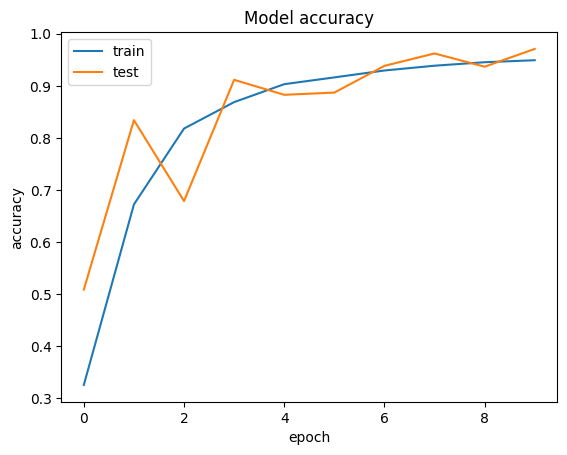

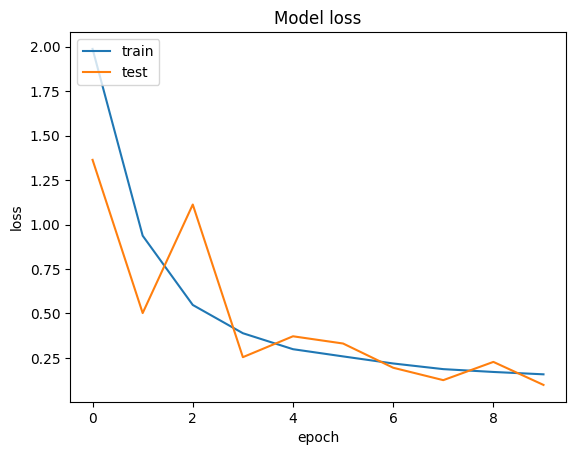

In [52]:
def plot_history(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    
plot_history(history)

141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9708 - loss: 0.0980
Accuracy: 97.08%, Loss: 0.0980
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step


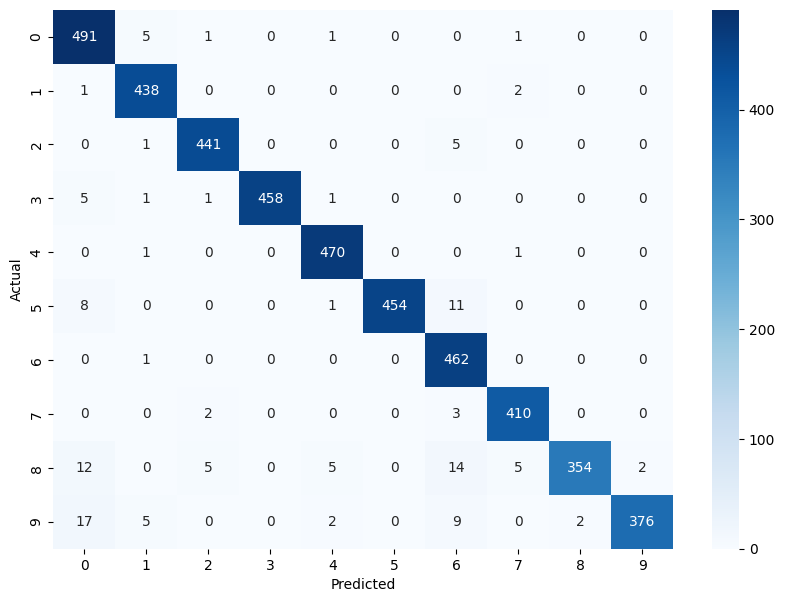

In [51]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f"Accuracy: {acc*100:.2f}%, Loss: {loss:.4f}")

y_pred_classes = np.argmax(model.predict(X_test), axis=1)
y_test_classes = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_classes, y_pred_classes), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()